In [39]:
from __future__ import annotations
from typing import Dict, List, Tuple, Optional, Union, Any
import pandas as pd
import numpy as np
import zarr

### The actual use cases  code is below the classes and functions

In [40]:
import zarr
import pandas as pd
import numpy as np
from typing import Tuple, Dict, List, Optional, Union

class DateRangeSplitter:
    """
    Splits Zarr dataset indices based on UTC date ranges.
    Designed for 2026 Zarr V3 and V2 standards.
    """
    def __init__(
        self,
        train_range: Tuple[str, str],
        val_range: Tuple[str, str],
        test_range: Tuple[str, str],
        zarr_path: Optional[str] = None,
        zarr_mode: str = "r",
        zarr_group: Optional[str] = None,
        time_key: str = "valid_time"
    ):
        self.ranges = {
            "train": train_range,
            "val": val_range,
            "test": test_range
        }
        self.time_key = time_key
        self._validate_ranges()

        self.root = None
        if zarr_path:
            # Best Practice: Use a context-safe open
            self.root = zarr.open(zarr_path, mode=zarr_mode)
            if zarr_group:
                self.root = self.root[zarr_group]

    def _validate_ranges(self):
        """Ensures start dates are chronologically before end dates."""
        for split, (start, end) in self.ranges.items():
            if pd.Timestamp(start) > pd.Timestamp(end):
                raise ValueError(f"Invalid {split} range: {start} > {end}")

    def _load_timestamps_from_zarr(self) -> pd.DatetimeIndex:
        """
        Loads and decodes timestamps. 
        Ensures alignment with UTC and correct time units.
        """
        if self.root is None:
            raise ValueError("Zarr root not initialized. Provide zarr_path.")
        
        if self.time_key not in self.root:
            raise KeyError(f"'{self.time_key}' not found in {list(self.root.keys())}")
        
        # 1. Fetch raw data
        time_arr = self.root[self.time_key]
        raw_values = time_arr[:]
        
        # 2. Extract units from metadata (fallback to seconds if missing)
        units_str = time_arr.attrs.get('units', 'seconds since 1970-01-01')
        
        # Extract the specific unit (seconds, days, etc.)
        # 'seconds since 1970-01-01' -> 's'
        unit_map = {'seconds': 's', 'minutes': 'm', 'hours': 'h', 'days': 'D'}
        unit_key = units_str.split(' ')[0].lower()
        pd_unit = unit_map.get(unit_key, 's')

        # 3. Decode to UTC-aware DatetimeIndex
        return pd.to_datetime(raw_values, unit=pd_unit, origin='unix', utc=True)

    def get_splits(
        self, 
        timestamps: Optional[Union[pd.DatetimeIndex, np.ndarray]] = None
    ) -> Dict[str, List[int]]:
        """
        Returns a dictionary of indices for each split range.
        """
        if timestamps is None:
            timestamps = self._load_timestamps_from_zarr()
        
        # Ensure timestamps are a DatetimeIndex and UTC-localized
        if not isinstance(timestamps, pd.DatetimeIndex):
            timestamps = pd.to_datetime(timestamps, unit='s', utc=True)
        elif timestamps.tz is None:
            timestamps = timestamps.tz_localize('UTC')

        results = {}
        for split_name, (start_str, end_str) in self.ranges.items():
            # Force range boundaries to UTC for a direct comparison
            start_ts = pd.Timestamp(start_str, tz='UTC')
            end_ts = pd.Timestamp(end_str, tz='UTC')

            mask = (timestamps >= start_ts) & (timestamps <= end_ts)
            indices = np.where(mask)[0]

            results[split_name] = indices.tolist()
            
            # Developer Hint: Log the findings
            print(f"✔ {split_name.capitalize()}: {len(indices)} samples found.")

        return results

# --- Example Usage ---
# splitter = DateRangeSplitter(
#     train_range=("2024-01-01", "2024-02-15"),
#     val_range=("2024-02-20", "2024-02-28"),
#     test_range=("2024-03-01", "2024-03-12"),
#     zarr_path="path/to/data.zarr"
# )
# splits = splitter.get_splits()

In [41]:
import torch

class ZarrNormalizer:
    """
    Handles Z-score normalization and de-normalization using 
    channel-wise statistics (mean, std).
    """
    def __init__(self, mean: torch.Tensor, std: torch.Tensor):
        # Reshape stats to (C, 1, 1) to allow broadcasting over (C, H, W)
        self.mean = mean.view(-1, 1, 1)
        self.std = std.view(-1, 1, 1)
        
        # Avoid division by zero
        self.std[self.std == 0] = 1.0

    def normalize(self, tensor: torch.Tensor) -> torch.Tensor:
        return (tensor - self.mean) / self.std

    def denormalize(self, tensor: torch.Tensor) -> torch.Tensor:
        return (tensor * self.std) + self.mean

In [53]:
import torch

class ZarrSymmetricNormalizer:
    """
    Handles Symmetric Min-Max normalization to the range [-scaling, scaling].
    Formula: scaling scaling*(2 * (x - min) / (max - min) - 1)
    """
    def __init__(self, min_val: torch.Tensor, max_val: torch.Tensor, scaling = 1.0):
        # Reshape to (C, 1, 1) for broadcasting over (C, H, W)
        self.min = min_val.view(-1, 1, 1)
        self.max = max_val.view(-1, 1, 1)
        
        # Calculate range and handle constant-value variables
        self.range = self.max - self.min
        self.range[self.range == 0] = 1.0  # Avoid division by zero
        self.scaling = scaling
        self.sclaing_inv = 1./scaling

    def normalize(self, tensor: torch.Tensor) -> torch.Tensor:
        """Maps data from [min, max] to [-scaling, scaling]"""
        return self.scaling * (2 * (tensor - self.min) / self.range - 1)

    def denormalize(self, tensor: torch.Tensor) -> torch.Tensor:
        """Maps data from [-scaling, scaling] back to [min, max]"""
        return (self.sclaing_inv*tensor + 1) * self.range / 2 + self.min

In [54]:
import zarr
import torch
from torch.utils.data import Dataset
import numpy as np

class ZarrWeatherDataset(Dataset):
    def __init__(
        self, 
        zarr_path: str, 
        indices: list, 
        variables: list, 
        normalizer: Optional = None
    ):
        """
        Args:
            zarr_path: Path to the .zarr store.
            indices: List of global indices for this split (e.g., splits['train']).
            variables: List of array names to stack as channels.
            normalizer: An instance of ZarrNormalizer.
        """
        self.store = zarr.open(zarr_path, mode='r')
        self.indices = indices
        self.variables = variables
        self.normalizer = normalizer

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # 1. Map local index to the global Zarr index from our splitter
        global_idx = self.indices[idx]
        
        data_list = []
        for var in self.variables:
            # Slicing zarr directly is efficient; it only loads the required chunk
            # Shape: (1, 256, 256) -> squeeze to (256, 256)
            data = self.store[var][global_idx].astype(np.float32)
            data_list.append(data)
        
        # 2. Stack into (Channels, Height, Width)
        # Using np.stack is faster before converting to torch.tensor
        tensor = torch.from_numpy(np.stack(data_list, axis=0))
        
        # 3. Apply Normalization
        if self.normalizer:
            tensor = self.normalizer.normalize(tensor)
            
        return tensor

In [44]:
def print_zarr_info(item, indent=0):
    """
    Standard inspection function for Zarr hierarchies.
    Handles V2/V3 transition and avoids DeprecationWarnings.
    """
    prefix = "  " * indent
    name = item.name.split("/")[-1] or "Root"

    if isinstance(item, zarr.Group):
        print(f"{prefix}📂 Group: {name}")
        if item.attrs is not None:
            print(f"{prefix}   ├─ Attrs: {dict(item.attrs)}")
        
        # Consistent sorting is a developer best practice
        for key in sorted(item.keys()):
            print_zarr_info(item[key], indent + 1)

    elif isinstance(item, zarr.Array):
        print(f"{prefix}📄 Array: {name}")
        print(f"{prefix}   ├─ Shape:  {item.shape}")
        print(f"{prefix}   ├─ Dtype:  {item.dtype}")
        print(f"{prefix}   ├─ Chunks: {item.chunks}")
        
        # Professional Handling of Compression Pipeline
        # 1. Check for modern .compressors (plural)
        if hasattr(item, 'compressors') and item.compressors:
            c_names = [type(c).__name__ for c in item.compressors]
            print(f"{prefix}   ├─ Codecs: {', '.join(c_names)}")
        # 2. Legacy fallback for older Zarr V2 objects
        elif hasattr(item, 'compressor') and item.compressor:
            print(f"{prefix}   ├─ Codec:  {type(item.compressor).__name__}")
        else:
            print(f"{prefix}   ├─ Codec:  None")

        if item.attrs is not None:
                print(f"{prefix}   └─ Attrs:  {dict(item.attrs)}")

# Usage
# store = zarr.open(zarr_path, mode='r')
# print_zarr_info(store)

In [57]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def plot_normalization_check(original, normalized, denormalized, var_names=None):
    """
    Visualizes the normalization pipeline across 3 columns.
    Ensures Original and Denormalized share the same color scale.
    """
    # Move to CPU and numpy if necessary
    orig_np = original.detach().cpu().numpy()
    norm_np = normalized.detach().cpu().numpy()
    denorm_np = denormalized.detach().cpu().numpy()
    
    C = orig_np.shape[0]
    if var_names is None:
        var_names = [f"Channel {i}" for i in range(C)]

    # Create subplot grid (Rows: Variables, Cols: Orig, Norm, Denorm)
    fig, axes = plt.subplots(C, 3, figsize=(15, 4 * C), constrained_layout=True)
    
    # Handle single channel edge case
    if C == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(C):
        # 1. Determine Shared Scale for reconstruction check
        v_min, v_max = orig_np[i].min(), orig_np[i].max()
        
        # --- Column 1: Original ---
        im0 = axes[i, 0].imshow(orig_np[i], cmap='viridis', vmin=v_min, vmax=v_max)
        axes[i, 0].set_title(f"{var_names[i]}\nOriginal\nMin: {v_min:.2f}, Max: {v_max:.2f}")
        plt.colorbar(im0, ax=axes[i, 0], fraction=0.046, pad=0.04)
        
        # --- Column 2: Normalized ---
        # Using a diverging colormap (RdBu_r) is best for symmetric [-1, 1] ranges
        im1 = axes[i, 1].imshow(norm_np[i], cmap='RdBu_r', vmin=-1, vmax=1)
        axes[i, 1].set_title(f"Normalized (Symmetric)\nMin: {norm_np[i].min():.2f}, Max: {norm_np[i].max():.2f}")
        plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)
        
        # --- Column 3: Denormalized ---
        # CRITICAL: We pass the vmin/vmax of the ORIGINAL to verify visual parity
        im2 = axes[i, 2].imshow(denorm_np[i], cmap='viridis', vmin=v_min, vmax=v_max)
        axes[i, 2].set_title(f"Denormalized\nMin: {denorm_np[i].min():.2f}, Max: {denorm_np[i].max():.2f}")
        plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

        # Cleanup: Remove axis ticks for cleaner spatial imagery
        for j in range(3):
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

    plt.savefig("normalization_report.png", dpi=200)
    print("✔ Plot saved to 'normalization_report.png'")

In [45]:
import zarr
import pandas as pd
import numpy as np

def print_zarr_times(zarr_array, indices):
    """
    Decodes and prints UTC timestamps for specific indices in a Zarr time array.
    
    Args:
        zarr_array: The zarr.Array object (e.g., store['valid_time'])
        indices: A list or range of integer indices to inspect.
    """
    # 1. Extract metadata
    units = zarr_array.attrs.get('units', 'seconds since 1970-01-01')
    calendar = zarr_array.attrs.get('calendar', 'proleptic_gregorian')
    
    # 2. Fetch only the required data (Efficiency: don't load the whole array)
    try:
        raw_values = zarr_array.get_orthogonal_selection(indices)
    except AttributeError:
        # Fallback for older versions or simple slicing
        raw_values = np.array([zarr_array[i] for i in indices])

    # 3. Decode using Pandas (Standard for 'proleptic_gregorian')
    # unit='s' matches your 'seconds since...' metadata
    decoded_times = pd.to_datetime(raw_values, unit='s', origin='unix', utc=True)

    # 4. Print in an arranged way
    print(f"📅 Time Variable: {zarr_array.name.split('/')[-1]}")
    print(f"   Units: {units} | Calendar: {calendar}")
    print("-" * 50)
    for idx, timestamp in zip(indices, decoded_times):
        print(f"Index [{idx:4}]: {timestamp.strftime('%Y-%m-%d %H:%M:%S')} UTC")

# Usage Example:
# print_zarr_times(store['valid_time'], [0, 10, 100, 3652])

In [46]:
zarr_path = '/ec/res4/scratch/smcd/output/yarong_data/cera_era5_256x256.zarr' 

In [47]:
zarr_group = None
store = zarr.open(zarr_path, mode='r')
root = store[zarr_group] if zarr_group else store

In [48]:
print_zarr_info(store)

📂 Group: Root
   ├─ Attrs: {}
  📄 Array: latitude
     ├─ Shape:  (256, 256)
     ├─ Dtype:  float64
     ├─ Chunks: (256, 256)
     ├─ Codecs: Blosc
     └─ Attrs:  {'units': 'degrees_north', 'standard_name': 'latitude', 'long_name': 'latitude', '_ARRAY_DIMENSIONS': ['y', 'x']}
  📄 Array: longitude
     ├─ Shape:  (256, 256)
     ├─ Dtype:  float64
     ├─ Chunks: (256, 256)
     ├─ Codecs: Blosc
     └─ Attrs:  {'units': 'degrees_east', 'standard_name': 'longitude', 'long_name': 'longitude', '_ARRAY_DIMENSIONS': ['y', 'x']}
  📄 Array: max
     ├─ Shape:  (4,)
     ├─ Dtype:  float64
     ├─ Chunks: (4,)
     ├─ Codecs: Blosc
     └─ Attrs:  {'_ARRAY_DIMENSIONS': ['variable']}
  📄 Array: mean
     ├─ Shape:  (4,)
     ├─ Dtype:  float64
     ├─ Chunks: (4,)
     ├─ Codecs: Blosc
     └─ Attrs:  {'_ARRAY_DIMENSIONS': ['variable']}
  📄 Array: min
     ├─ Shape:  (4,)
     ├─ Dtype:  float64
     ├─ Chunks: (4,)
     ├─ Codecs: Blosc
     └─ Attrs:  {'_ARRAY_DIMENSIONS': ['variable']}
  

In [49]:
print_zarr_times(store['valid_time'], [0, 10, 100, 3652])

📅 Time Variable: valid_time
   Units: seconds since 1970-01-01 | Calendar: proleptic_gregorian
--------------------------------------------------
Index [   0]: 2015-01-01 00:00:00 UTC
Index [  10]: 2015-01-11 00:00:00 UTC
Index [ 100]: 2015-04-11 00:00:00 UTC
Index [3652]: 2024-12-31 00:00:00 UTC


In [50]:
# 2. Initialize the Splitter
# We define specific blocks for train, validation, and testing
splitter = DateRangeSplitter(
    train_range=("2015-01-01", "2015-01-15"),
    val_range=("2024-12-01", "2024-12-15"),
    test_range=("2024-12-16", "2024-12-31"),
    zarr_path=zarr_path
)

# 3. Generate Splits
# Since we provided zarr_path and it defaults to time_key="timestamp", 
# we don't need to pass any arguments.
splits = splitter.get_splits()

✔ Train: 15 samples found.
✔ Val: 15 samples found.
✔ Test: 16 samples found.


In [51]:
print(splits)

{'train': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14], 'val': [3622, 3623, 3624, 3625, 3626, 3627, 3628, 3629, 3630, 3631, 3632, 3633, 3634, 3635, 3636], 'test': [3637, 3638, 3639, 3640, 3641, 3642, 3643, 3644, 3645, 3646, 3647, 3648, 3649, 3650, 3651, 3652]}


# Test with Symetric Normalizer

In [66]:
# 1. Load Statistics from Zarr metadata
z = zarr.open(zarr_path, mode='r')
# Convert the stored 'min' and 'max' arrays to torch tensors
min_val_stats = torch.from_numpy(z['min'][:].astype(np.float32))
max_val_stats = torch.from_numpy(z['max'][:].astype(np.float32))

# 2. Initialize Normalizer
normalizer = ZarrSymmetricNormalizer(min_val=min_val_stats, max_val=max_val_stats, scaling = 1)

# 3. Define Variables (order must match the order in mean/std arrays)
target_vars = ['t2m_cerra_mean', 't2m_cerra_std', 't2m_era5_mean', 't2m_era5_std']

# 4. Create Datasets
train_dataset_normalized = ZarrWeatherDataset(
    zarr_path=zarr_path,
    indices=splits['train'],
    variables=target_vars,
    normalizer=normalizer
)

train_dataset_not_normalized = ZarrWeatherDataset(
    zarr_path=zarr_path,
    indices=splits['train'],
    variables=target_vars,
    normalizer=None
)

ds_index = 0 
# Example: Get first sample
original_sample = train_dataset_not_normalized[ds_index]
normalized_sample = train_dataset_normalized[ds_index]
denormalized_sample = normalizer.denormalize(normalized_sample)
print(f"original_sample shape: {original_sample.shape}") 
print(f"normalized_sample shape: {original_sample.shape}") 
print(f"denormalized_sample shape: {original_sample.shape}") 

original_sample shape: torch.Size([4, 256, 256])
normalized_sample shape: torch.Size([4, 256, 256])
denormalized_sample shape: torch.Size([4, 256, 256])


✔ Plot saved to 'normalization_report.png'


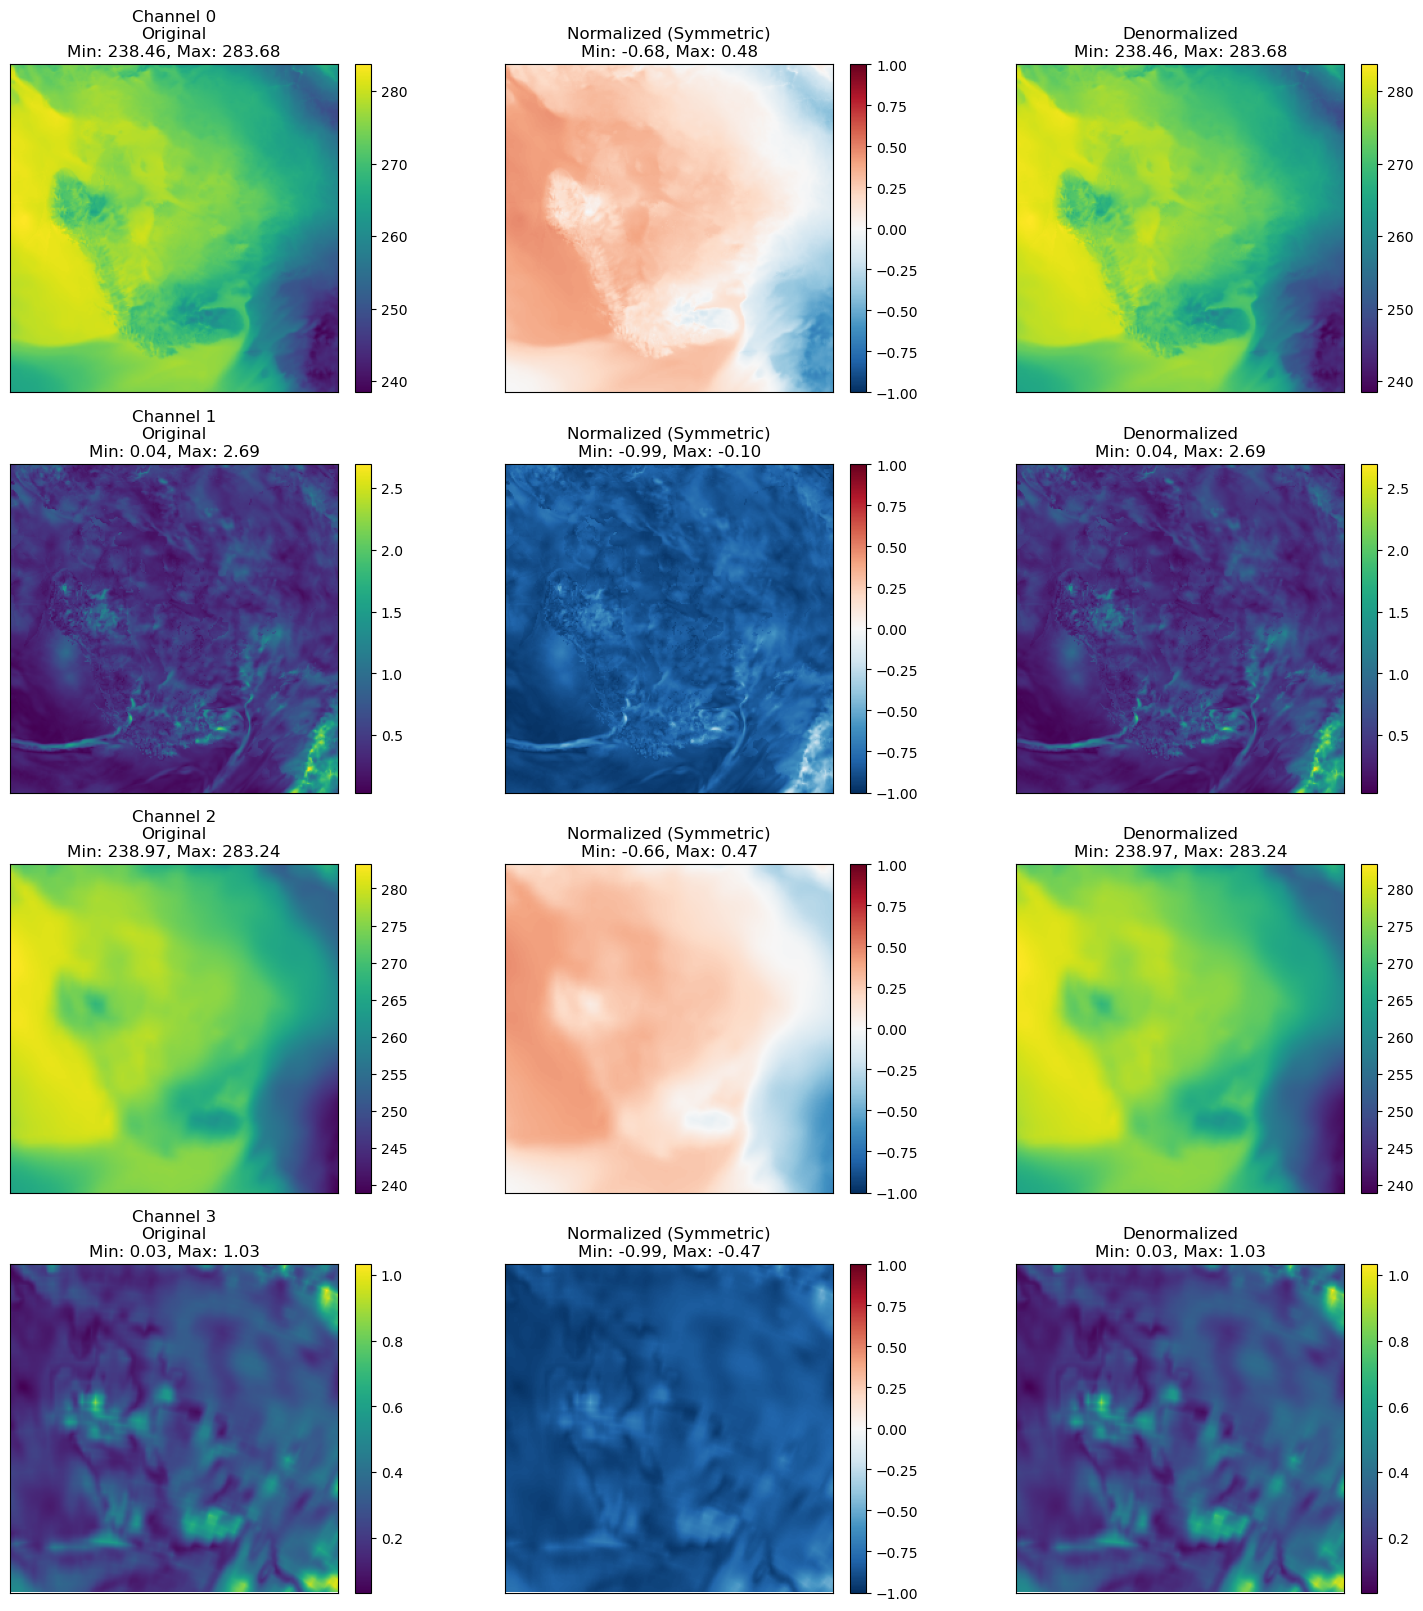

In [67]:
plot_normalization_check(original_sample, normalized_sample, denormalized_sample)

# Test with Natural Normalizer

In [34]:
# 1. Load Statistics from Zarr metadata
z = zarr.open(zarr_path, mode='r')
# Convert the stored 'mean' and 'std' arrays to torch tensors
mean_stats = torch.from_numpy(z['mean'][:].astype(np.float32))
std_stats = torch.from_numpy(z['std'][:].astype(np.float32))

# 2. Initialize Normalizer
normalizer = ZarrNormalizer(mean=mean_stats, std=std_stats)

# 3. Define Variables (order must match the order in mean/std arrays)
target_vars = ['t2m_cerra_mean', 't2m_cerra_std', 't2m_era5_mean', 't2m_era5_std']

# 4. Create Datasets
train_dataset = ZarrWeatherDataset(
    zarr_path=zarr_path,
    indices=splits['train'],
    variables=target_vars,
    normalizer=normalizer
)

# Example: Get first sample
sample = train_dataset[0]
print(f"Sample shape: {sample.shape}") # Expected: torch.Size([4, 256, 256])

Sample shape: torch.Size([4, 256, 256])


In [72]:
# 1. Load Statistics from Zarr metadata
z = zarr.open(zarr_path, mode='r')
# Convert the stored 'mean' and 'std' arrays to torch tensors
mean_stats = torch.from_numpy(z['mean'][:].astype(np.float32))
std_stats = torch.from_numpy(z['std'][:].astype(np.float32))

# 2. Initialize Normalizer
normalizer = ZarrNormalizer(mean=mean_stats, std=std_stats)

# 3. Define Variables (order must match the order in mean/std arrays)
target_vars = ['t2m_cerra_mean', 't2m_cerra_std', 't2m_era5_mean', 't2m_era5_std']

# 4. Create Datasets
train_dataset_normalized = ZarrWeatherDataset(
    zarr_path=zarr_path,
    indices=splits['train'],
    variables=target_vars,
    normalizer=normalizer
)

train_dataset_not_normalized = ZarrWeatherDataset(
    zarr_path=zarr_path,
    indices=splits['train'],
    variables=target_vars,
    normalizer=None
)

ds_index = 0 
# Example: Get first sample
original_sample_n = train_dataset_not_normalized[ds_index]
normalized_sample_n = train_dataset_normalized[ds_index]
denormalized_sample_n = normalizer.denormalize(normalized_sample_n)
print(f"original_sample shape: {original_sample.shape}") 
print(f"normalized_sample shape: {original_sample.shape}") 
print(f"denormalized_sample shape: {original_sample.shape}") 

original_sample shape: torch.Size([4, 256, 256])
normalized_sample shape: torch.Size([4, 256, 256])
denormalized_sample shape: torch.Size([4, 256, 256])


✔ Plot saved to 'normalization_report.png'


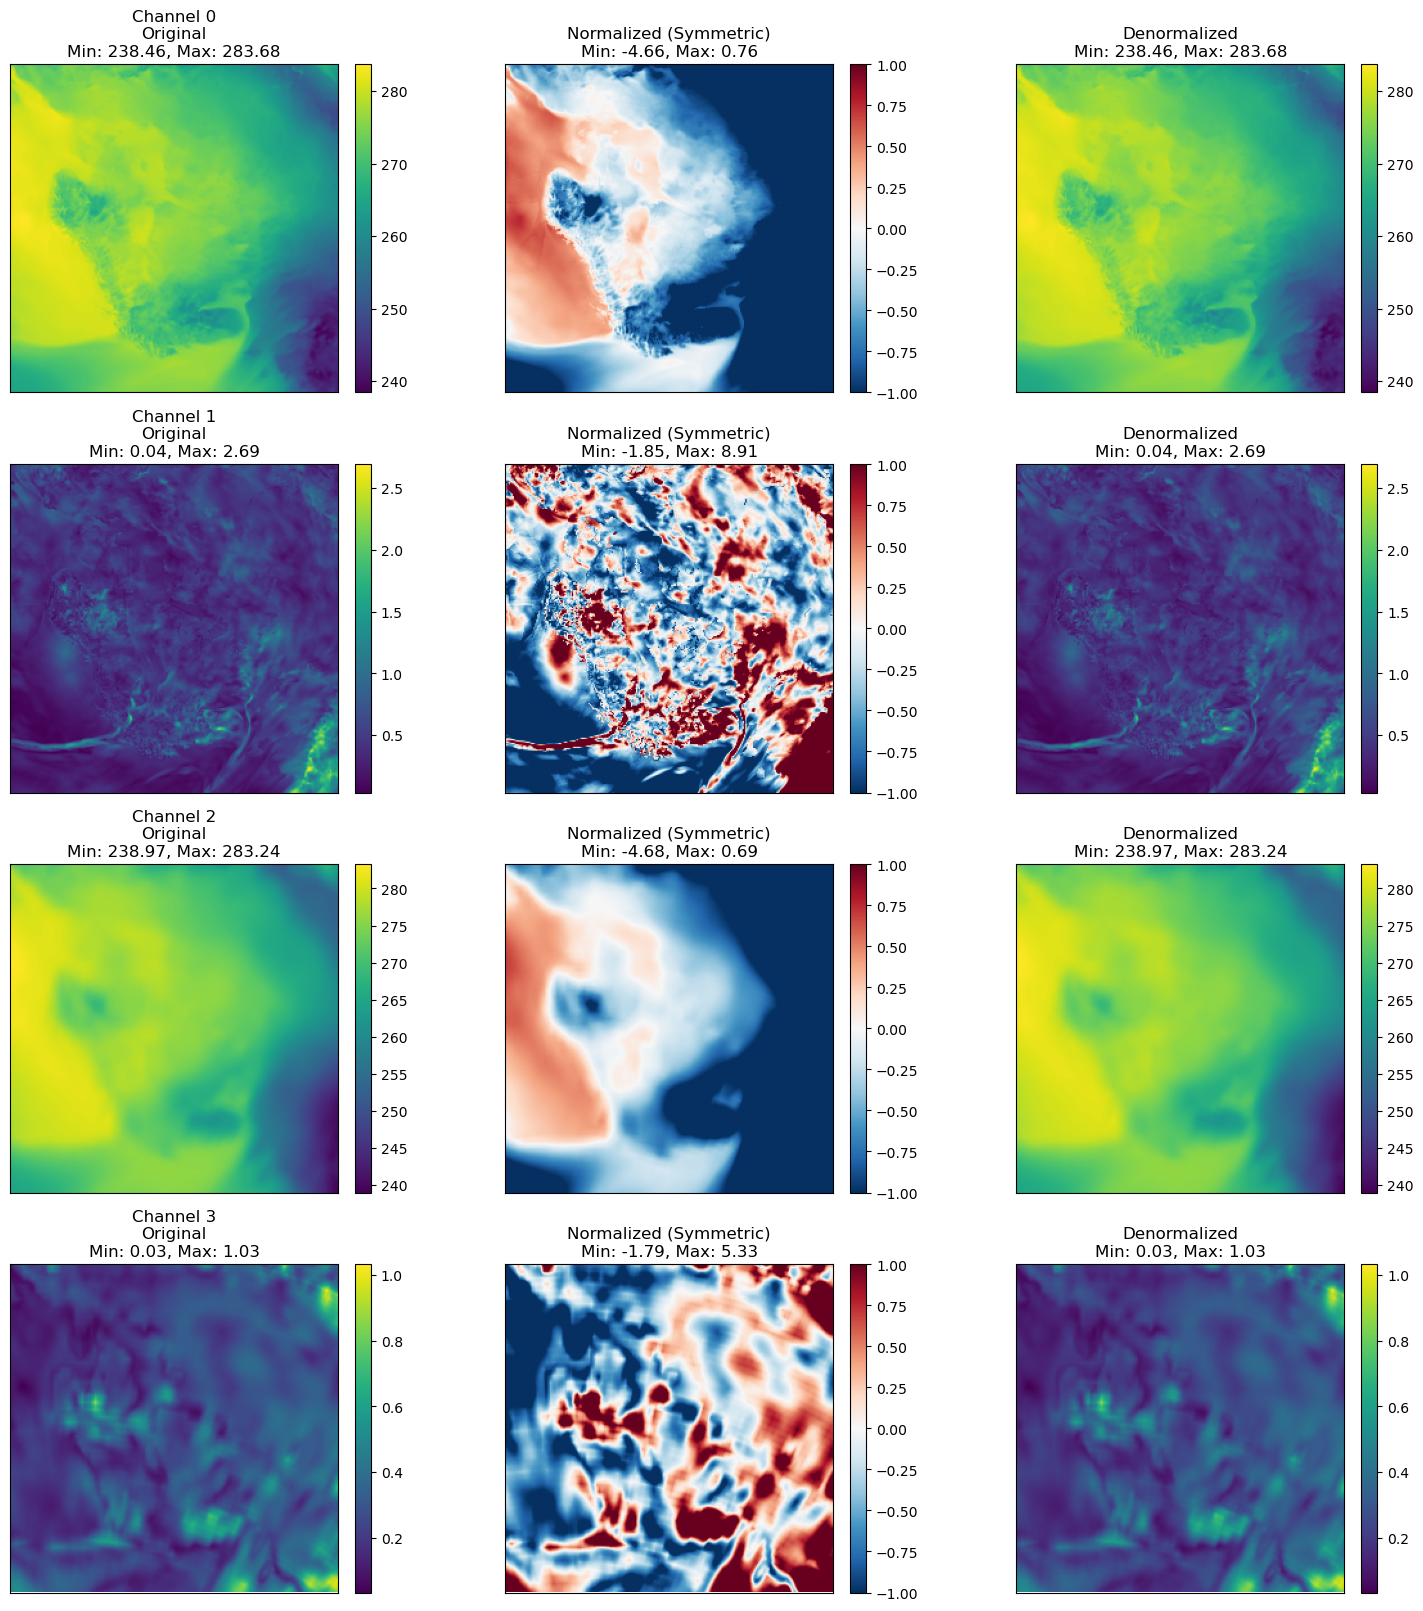

In [73]:
plot_normalization_check(original_sample_n, normalized_sample_n, denormalized_sample_n)

DataLoader Example